# Job Demand Analysis in Germany

## Executive Summary

This notebook analyzes demand for data-related job roles in Germany using the Data Jobs dataset from Hugging Face.

### Business Questions

- Which data roles are most frequently advertised in Germany?
- How does hiring demand change throughout the year?
- Which months experience the highest and lowest hiring activity?
- What trends can be observed among the most demanded data careers?

The analysis identifies the most frequently advertised data roles and examines their monthly demand patterns throughout 2023.

In [1]:
import pandas as pd
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Dataset Overview

The Data Jobs dataset contains job postings collected from multiple online sources.

For this analysis:

- Only German job postings are considered.
- Posting dates are converted into monthly periods.
- Demand is measured as the number of job advertisements.

In [2]:
dataset = load_dataset("lukebarousse/data_jobs")

df = dataset["train"].to_pandas()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 785,741
Columns: 17


## Data Preparation

The posting date is converted into datetime format and the dataset is filtered to include only jobs located in Germany.

The sample below shows the key fields used throughout the analysis.

In [3]:
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

df_de = df[df["job_country"] == "Germany"].copy()

print(f"German job postings: {len(df_de):,}")

df_de[
    [
        "job_title_short",
        "job_country",
        "job_posted_date"
    ]
].sample(10, random_state=42)

German job postings: 27,694


,job_title_short,job_country,job_posted_date
613792,Data Analyst,Germany,2023-10-05 12:14:06
312226,Senior Data Engineer,Germany,2023-02-20 17:17:14
387834,Data Scientist,Germany,2023-12-12 18:33:31
286607,Senior Data Scientist,Germany,2023-02-11 17:15:25
652678,Data Analyst,Germany,2023-10-19 10:35:27
664121,Data Analyst,Germany,2023-10-25 10:15:19
682050,Senior Data Engineer,Germany,2023-01-10 10:39:29
354951,Data Analyst,Germany,2023-01-01 23:36:07
209755,Data Engineer,Germany,2023-11-29 22:18:16
306428,Data Scientist,Germany,2023-11-09 17:18:30


## Monthly Aggregation

A monthly period column is created to support time-series analysis.

In [4]:
df_de["job_posted_month"] = (
    df_de["job_posted_date"]
    .dt.to_period("M")
    .astype(str)
)

## Executive Metrics

Key statistics derived from German data job postings in 2023.

In [5]:
role_counts = (
    df_de["job_title_short"]
    .value_counts()
)

total_postings = len(df_de)

top_role = role_counts.index[0]
top_role_count = role_counts.iloc[0]

peak_month = (
    df_de["job_posted_month"]
    .value_counts()
    .sort_index()
    .idxmax()
)

lowest_month = (
    df_de["job_posted_month"]
    .value_counts()
    .sort_index()
    .idxmin()
)

metrics = pd.DataFrame({
    "Metric": [
        "Total German Job Postings",
        "Most Demanded Role",
        "Postings for Top Role",
        "Peak Hiring Month",
        "Lowest Hiring Month"
    ],
    "Value": [
        f"{total_postings:,}",
        top_role,
        f"{top_role_count:,}",
        peak_month,
        lowest_month
    ]
})

metrics

,Metric,Value
0,Total German Job Postings,"27,694"
1,Most Demanded Role,Data Analyst
2,Postings for Top Role,"7,131"
3,Peak Hiring Month,2023-10
4,Lowest Hiring Month,2023-05


## Most Demanded Data Roles

The table below ranks the ten most frequently advertised data-related positions in Germany.

In [6]:
top_roles_table = (
    role_counts
    .head(10)
    .reset_index()
)

top_roles_table.columns = [
    "Job Title",
    "Postings"
]

top_roles_table.index += 1

top_roles_table

,Job Title,Postings
1,Data Analyst,7131
2,Data Scientist,6745
3,Data Engineer,6675
4,Senior Data Engineer,2041
5,Senior Data Scientist,1737
6,Senior Data Analyst,1216
7,Business Analyst,817
8,Software Engineer,741
9,Machine Learning Engineer,402
10,Cloud Engineer,189


## Job Role Popularity

This chart compares the number of postings for the ten most demanded data-related roles in Germany.

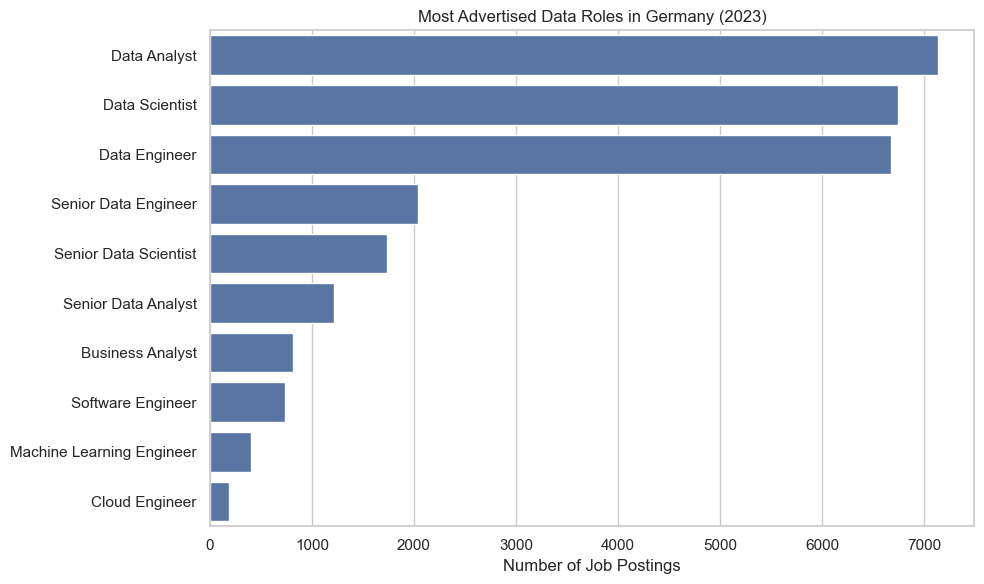

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_roles_table,
    x="Postings",
    y="Job Title"
)

plt.title("Most Advertised Data Roles in Germany (2023)")
plt.xlabel("Number of Job Postings")
plt.ylabel("")

plt.tight_layout()
plt.show()

## Top Job Roles

The three most frequently occurring data-related job titles are selected for trend analysis.

In [8]:
top_3 = role_counts.head(3).index.tolist()

top_3

['Data Analyst', 'Data Scientist', 'Data Engineer']

## Pivot Table Creation

The pivot table below summarizes monthly job posting counts for each major data-related role in Germany.

In [9]:
df_de_pivot = df_de.pivot_table(
    index="job_posted_month",
    columns="job_title_short",
    aggfunc="size",
    fill_value=0
)

df_de_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
2023-01,46,11,596,622,759,39,128,239,205,52
2023-02,49,11,593,571,611,35,131,199,171,60
2023-03,43,3,582,511,529,18,86,199,157,42
2023-04,47,13,454,432,520,17,93,190,146,20
2023-05,45,7,430,364,351,16,81,123,111,29
2023-06,31,7,558,434,430,22,92,137,138,30
2023-07,46,7,545,474,438,25,105,143,125,50
2023-08,28,9,489,399,407,30,86,145,141,48
2023-09,106,24,656,668,583,41,126,178,137,66


## Monthly Demand Dataset

The data is reshaped into a format suitable for visualization.

In [10]:
monthly_counts = (
    df_de
    .groupby(["job_posted_month", "job_title_short"])
    .size()
    .reset_index(name="Job Count")
)

plot_data = monthly_counts[
    monthly_counts["job_title_short"].isin(top_3)
].copy()

plot_data.rename(
    columns={"job_title_short": "Job Title"},
    inplace=True
)

## Monthly Demand Trends

The chart below shows monthly job posting volumes for the three most common data careers in Germany.

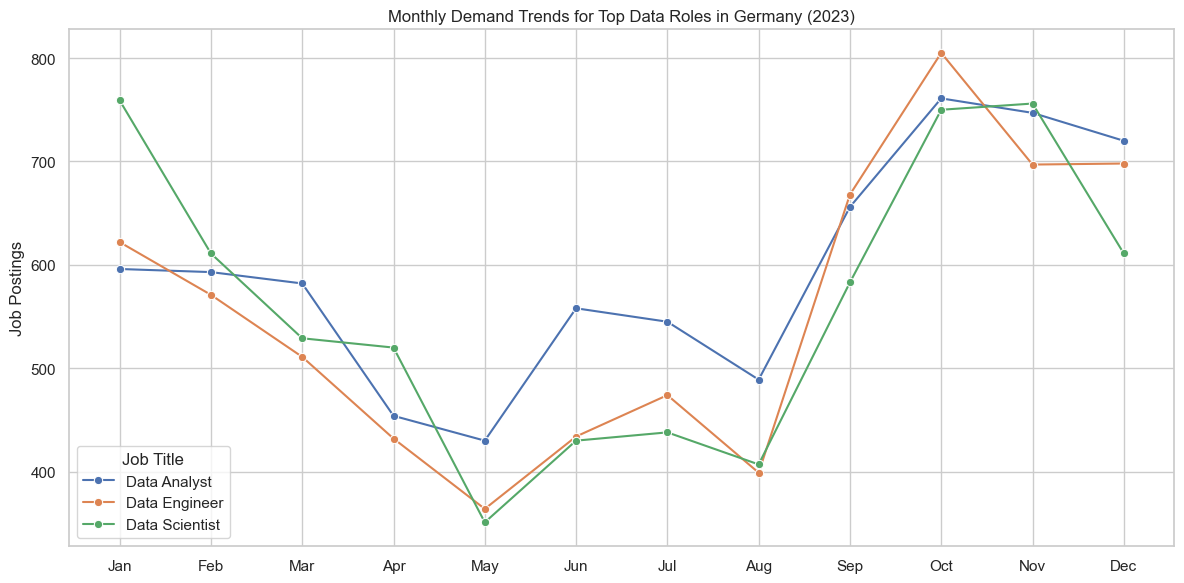

In [11]:
plot_data["Month"] = pd.to_datetime(
    plot_data["job_posted_month"]
).dt.strftime("%b")

month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=plot_data,
    x="Month",
    y="Job Count",
    hue="Job Title",
    marker="o"
)

plt.title(
    "Monthly Demand Trends for Top Data Roles in Germany (2023)"
)

plt.xlabel("")
plt.ylabel("Job Postings")

plt.xticks(
    ticks=range(len(month_order)),
    labels=month_order,
    rotation=0
)

plt.legend(title="Job Title")

plt.tight_layout()

plt.show()

## Key Findings

1. Data Analyst was the most frequently advertised data role in Germany, with more than 7,000 job postings.
2. Data Scientist and Data Engineer positions closely followed, indicating strong demand across analytics, machine learning, and data infrastructure functions.
3. Hiring activity declined during the middle of the year and reached its lowest point in May.
4. Demand increased significantly during the fourth quarter, with October recording the highest hiring activity of the year.
5. The simultaneous increase across all three leading roles suggests a broad market-wide hiring expansion rather than demand concentrated in a single specialty.

## Limitations

- The analysis uses only job postings available within the Data Jobs dataset.
- Job posting counts measure hiring demand indirectly and do not represent actual hires.
- The study focuses exclusively on Germany and may not generalize to other markets.
- Results are based on 2023 postings and may not reflect current labor market conditions.

# Conclusion

This analysis examined more than 27,000 German data-related job postings from 2023 to identify the most demanded roles and their hiring patterns.

Key conclusions:

- Data Analyst was the most advertised role in Germany.
- Data Scientist and Data Engineer positions showed similarly strong demand.
- Hiring activity declined during the middle of the year before recovering sharply in Q4.
- October recorded the highest hiring activity among all months analyzed.
- The simultaneous growth of multiple roles suggests broad expansion across the German data job market rather than demand concentrated in a single specialization.

Overall, the results indicate sustained demand for analytical, engineering, and machine learning capabilities within Germany's data ecosystem.